# Chapter 19: Building Production Prompt Systems — From Prototype to Pipeline

**Book:** Design of Agentic Systems with Case Studies — Prompt Engineering with LLMs  
**Course:** INFO 7375 — Prompt Engineering for Generative AI, Northeastern University  
**Chapter Type:** Type E — Operational / Production Practice  
**Master Argument:** Architecture is the leverage point, not the model.

---

## Core Claim

A prompt that works in prototyping breaks silently in production because there
is no versioning, no evaluation loop, no fallback when the LLM response degrades.
**The architecture causes the failure — not the model.**

## Learning Outcomes

1. **Analyze** the architectural gap between a prototype prompt workflow and a production pipeline.
2. **Design** a prompt management pipeline with version control, schema validation, and evaluation loops.
3. **Evaluate** a deployed prompt system's health by detecting semantic drift and output degradation.
4. **Implement** a fallback architecture that degrades gracefully under failure.
5. **Critique** a prompt deployment by tracing the causal chain from a missing component to an observable failure.

## Setup

This notebook is **fully runnable from a fresh clone** using mock LLM responses.
No API keys are required. Where real API calls would go, the code is clearly marked.

In [11]:
import json
import uuid
import time
import hashlib
import random
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from dataclasses import dataclass, field, asdict
from typing import Literal, Optional
from pydantic import BaseModel, ValidationError

random.seed(42)
np.random.seed(42)

print("✅ All dependencies loaded. Notebook is ready.")

✅ All dependencies loaded. Notebook is ready.


---
# PART 1: THE PROTOTYPE — What Most Teams Ship

The prototype pattern: a hardcoded prompt string embedded directly in application
code, with a direct LLM API call and raw JSON parsing of the response.
This is what 90% of LLM-powered features look like on launch day.

In [12]:
class MockOpenAI:
    """
    Simulates an LLM API with configurable behavior modes.
    
    In production, replace every call to mock_llm.generate(...) with:
        response = openai.chat.completions.create(
            model=model_name,
            messages=[{"role": "user", "content": prompt}],
            temperature=temperature
        )
        return response.choices[0].message.content
    """
    
    def __init__(self, mode="normal", failure_rate=0.0):
        self.mode = mode
        self.failure_rate = failure_rate
        self.call_count = 0
        
        self._normal_responses = [
            {"issue": "Login page returns 500 error after OAuth redirect",
             "sentiment": "negative", "priority": "High"},
            {"issue": "Dashboard charts not loading on mobile Safari",
             "sentiment": "negative", "priority": "Medium"},
            {"issue": "Positive feedback on new onboarding flow",
             "sentiment": "positive", "priority": "Low"},
            {"issue": "Payment processing timeout during checkout",
             "sentiment": "negative", "priority": "High"},
            {"issue": "Feature request for dark mode support",
             "sentiment": "neutral", "priority": "Low"},
            {"issue": "Cannot export CSV reports — button unresponsive",
             "sentiment": "negative", "priority": "Medium"},
        ]
        
        self._drifted_format_responses = [
            {"issue": "Login problem", "sentiment": "negative",
             "priority": "This seems quite urgent"},
            {"issue": "Chart display issue", "sentiment": "negative",
             "priority": "Moderately important"},
            {"issue": "User is happy", "sentiment": "positive",
             "priority": "Not a priority at all"},
            {"issue": "Payment issue", "sentiment": "negative",
             "priority": "Very high urgency"},
        ]
        
        self._drifted_semantic_responses = [
            {"issue": "Customer reported a problem", "sentiment": "neutral",
             "priority": "Medium"},
            {"issue": "User has a concern", "sentiment": "neutral",
             "priority": "Medium"},
            {"issue": "Ticket received", "sentiment": "neutral",
             "priority": "Low"},
            {"issue": "Issue reported by user", "sentiment": "neutral",
             "priority": "Medium"},
        ]
    
    def generate(self, prompt: str, model: str = "gpt-4",
                 temperature: float = 0.1) -> str:
        self.call_count += 1
        
        if random.random() < self.failure_rate:
            raise TimeoutError(
                f"API timeout after 30s (call #{self.call_count})")
        
        latency = random.uniform(0.05, 0.15)
        time.sleep(latency)
        
        if self.mode == "normal":
            prompt_lower = prompt.lower()
            if any(w in prompt_lower for w in ["furious", "angry", "broken", "not work", "hasn't work"]):
                resp = {"issue": "Login page returns 500 error after OAuth redirect",
                        "sentiment": "negative", "priority": "High"}
            elif any(w in prompt_lower for w in ["fantastic", "great", "love", "amazing"]):
                resp = {"issue": "Positive feedback on new onboarding flow",
                        "sentiment": "positive", "priority": "Low"}
            elif any(w in prompt_lower for w in ["urgent", "down", "revenue", "payment"]):
                resp = {"issue": "Payment processing timeout during checkout",
                        "sentiment": "negative", "priority": "High"}
            elif any(w in prompt_lower for w in ["typo", "minor", "annualy"]):
                resp = {"issue": "Typographical error on pricing page",
                        "sentiment": "neutral", "priority": "Low"}
            elif any(w in prompt_lower for w in ["feature", "request", "integration"]):
                resp = {"issue": "Feature request for Slack notification integration",
                        "sentiment": "neutral", "priority": "Low"}
            else:
                resp = random.choice(self._normal_responses)
        elif self.mode == "format_drift":
            resp = random.choice(self._drifted_format_responses)
        elif self.mode == "semantic_drift":
            resp = random.choice(self._drifted_semantic_responses)
        else:
            resp = random.choice(self._normal_responses)
        
        return json.dumps(resp)


def prototype_summarize_ticket(ticket_text: str, llm: MockOpenAI) -> dict:
    """THE PROTOTYPE PATTERN. One function, zero architecture."""
    prompt = f"""Summarize this support ticket into JSON with exactly three fields:
    - issue: one-sentence description
    - sentiment: positive, negative, or neutral
    - priority: High, Medium, or Low
    
    Ticket: {ticket_text}"""
    
    raw = llm.generate(prompt)
    return json.loads(raw)


print("=" * 60)
print("PART 1: THE PROTOTYPE (normal conditions)")
print("=" * 60)

normal_llm = MockOpenAI(mode="normal")
test_tickets = [
    "I'm furious. Login hasn't worked in 3 days and I've missed deadlines.",
    "Just wanted to say your new dashboard is fantastic! Love the dark mode.",
    "URGENT: payment processing is down, we're losing revenue every minute.",
    "Minor typo on the pricing page — 'annualy' should be 'annually'.",
    "Feature request: can you add Slack integration for notifications?",
]

print("\n🟢 Under normal conditions, the prototype works fine:\n")
for ticket in test_tickets:
    result = prototype_summarize_ticket(ticket, normal_llm)
    print(f"  Ticket: {ticket[:55]}...")
    print(f"  Result: {result}\n")

PART 1: THE PROTOTYPE (normal conditions)

🟢 Under normal conditions, the prototype works fine:

  Ticket: I'm furious. Login hasn't worked in 3 days and I've mis...
  Result: {'issue': 'Login page returns 500 error after OAuth redirect', 'sentiment': 'negative', 'priority': 'High'}

  Ticket: Just wanted to say your new dashboard is fantastic! Lov...
  Result: {'issue': 'Positive feedback on new onboarding flow', 'sentiment': 'positive', 'priority': 'Low'}

  Ticket: URGENT: payment processing is down, we're losing revenu...
  Result: {'issue': 'Payment processing timeout during checkout', 'sentiment': 'negative', 'priority': 'High'}

  Ticket: Minor typo on the pricing page — 'annualy' should be 'a...
  Result: {'issue': 'Typographical error on pricing page', 'sentiment': 'neutral', 'priority': 'Low'}

  Ticket: Feature request: can you add Slack integration for noti...
  Result: {'issue': 'Feature request for Slack notification integration', 'sentiment': 'neutral', 'priority': 'Low'

In [13]:
print("=" * 60)
print("PART 1: THE PROTOTYPE (after model update — format drift)")
print("=" * 60)

drifted_llm = MockOpenAI(mode="format_drift")

print("\n🔴 After a silent model update, the prototype breaks:\n")
for ticket in test_tickets[:3]:
    result = prototype_summarize_ticket(ticket, drifted_llm)
    valid_priorities = {"High", "Medium", "Low"}
    priority_valid = result.get("priority") in valid_priorities
    print(f"  Ticket:   {ticket[:55]}...")
    print(f"  Result:   {result}")
    print(f"  Priority: {'✅ Valid' if priority_valid else '❌ INVALID — would break routing queue'}\n")

print("⚠️  The API returned 200 OK. json.loads() succeeded.")
print("⚠️  No exception was raised. No alert fired.")
print("⚠️  The downstream routing queue silently drops these tickets.")
print("⚠️  Time to detection in production: ~48 hours (manual discovery).")

PART 1: THE PROTOTYPE (after model update — format drift)

🔴 After a silent model update, the prototype breaks:

  Ticket:   I'm furious. Login hasn't worked in 3 days and I've mis...
  Result:   {'issue': 'Login problem', 'sentiment': 'negative', 'priority': 'This seems quite urgent'}
  Priority: ❌ INVALID — would break routing queue

  Ticket:   Just wanted to say your new dashboard is fantastic! Lov...
  Result:   {'issue': 'Payment issue', 'sentiment': 'negative', 'priority': 'Very high urgency'}
  Priority: ❌ INVALID — would break routing queue

  Ticket:   URGENT: payment processing is down, we're losing revenu...
  Result:   {'issue': 'Login problem', 'sentiment': 'negative', 'priority': 'This seems quite urgent'}
  Priority: ❌ INVALID — would break routing queue

⚠️  The API returned 200 OK. json.loads() succeeded.
⚠️  No exception was raised. No alert fired.
⚠️  The downstream routing queue silently drops these tickets.
⚠️  Time to detection in production: ~48 hours (manual di

---
# PART 2: THE PRODUCTION PIPELINE — The Five Walls

| Wall | Blocks |
|------|--------|
| Prompt Registry | "Cannot rollback" |
| Schema Gate | "Format drift" |
| Evaluation Loop | "Semantic drift" |
| Fallback Cascade | "Total failure" |
| Observability Layer | "Invisible failure" |

In [14]:
# ============================================================
# WALL 1: PROMPT REGISTRY
# ============================================================

@dataclass
class PromptEntry:
    name: str
    version: str
    template: str
    model_config: dict
    active: bool = True
    golden_set: list = field(default_factory=list)
    metadata: dict = field(default_factory=dict)
    
    def render(self, **kwargs) -> str:
        return self.template.format(**kwargs)


class PromptRegistry:
    """
    Stores prompts as versioned artifacts, decoupled from application code.
    Note: This demo uses simple highest-active-version routing.
    The chapter describes traffic-weighted A/B routing via random.choices.
    """
    
    def __init__(self):
        self._store = {}
    
    def register(self, entry: PromptEntry):
        if entry.name not in self._store:
            self._store[entry.name] = {}
        self._store[entry.name][entry.version] = entry
        print(f"  📋 Registered: {entry.name} v{entry.version}"
              f" (active={entry.active})")
    
    def fetch(self, name: str, version: str = None) -> PromptEntry:
        versions = self._store.get(name, {})
        if not versions:
            raise KeyError(f"No prompt registered with name '{name}'")
        if version:
            return versions[version]
        active = [v for v in versions.values() if v.active]
        if not active:
            raise KeyError(f"No active version for prompt '{name}'")
        return max(active, key=lambda v: v.version)
    
    def rollback(self, name: str, to_version: str):
        for v in self._store[name].values():
            v.active = (v.version == to_version)
        print(f"  🔄 Rolled back '{name}' to v{to_version}")
    
    def list_versions(self, name: str) -> list:
        return [
            {"version": v.version, "active": v.active,
             "created": v.metadata.get("created", "unknown")}
            for v in self._store.get(name, {}).values()
        ]


print("=" * 60)
print("WALL 1: PROMPT REGISTRY — Registering prompt versions")
print("=" * 60)
print()

registry = PromptRegistry()

registry.register(PromptEntry(
    name="ticket_summary", version="1",
    template=("Summarize this support ticket into JSON with three fields: "
              "issue, sentiment, priority.\n\nTicket: {ticket_text}"),
    model_config={"model": "gpt-4", "temperature": 0.3},
    active=False,
    metadata={"author": "prototype-team", "created": "2025-01-10",
              "changelog": "Initial version — loose instructions"}
))

registry.register(PromptEntry(
    name="ticket_summary", version="2",
    template=("Summarize this support ticket into JSON with exactly three fields:\n"
              "- issue: a specific, one-sentence description of the technical problem\n"
              "- sentiment: exactly one of [positive, negative, neutral]\n"
              "- priority: exactly one of [High, Medium, Low]\n\n"
              "Respond with ONLY the JSON object, no other text.\n\n"
              "Ticket: {ticket_text}"),
    model_config={"model": "gpt-4", "temperature": 0.1},
    active=False,
    golden_set=[
        {"input": "Login broken for 3 days, furious",
         "expected": {"issue": "Login page returns 500 after OAuth redirect",
                      "sentiment": "negative", "priority": "High"}},
        {"input": "Love the new dashboard!",
         "expected": {"issue": "Positive feedback on dashboard redesign",
                      "sentiment": "positive", "priority": "Low"}},
        {"input": "Payment processing down, losing revenue",
         "expected": {"issue": "Payment processing timeout during checkout",
                      "sentiment": "negative", "priority": "High"}},
    ],
    metadata={"author": "ops-team", "created": "2025-02-20",
              "changelog": "Tightened enum constraints after format drift incident"}
))

registry.register(PromptEntry(
    name="ticket_summary", version="3",
    template=("You are a support ticket classifier. Analyze the ticket below and "
              "respond with a JSON object containing exactly three fields:\n"
              '- "issue": a specific one-sentence description of the technical problem\n'
              '- "sentiment": exactly one of "positive", "negative", or "neutral"\n'
              '- "priority": exactly one of "High", "Medium", or "Low"\n\n'
              "Rules:\n"
              "- Respond with ONLY valid JSON. No markdown, no explanation.\n"
              "- The issue field must describe the specific technical problem, "
              "not a vague summary.\n"
              "- Base priority on business impact: data loss or outage = High, "
              "functional bug = Medium, cosmetic or feature request = Low.\n\n"
              "Ticket: {ticket_text}"),
    model_config={"model": "gpt-4", "temperature": 0.1},
    active=True,
    golden_set=[
        {"input": "Login broken for 3 days, furious",
         "expected": {"issue": "Login page returns 500 after OAuth redirect",
                      "sentiment": "negative", "priority": "High"}},
        {"input": "Love the new dashboard!",
         "expected": {"issue": "Positive feedback on dashboard redesign",
                      "sentiment": "positive", "priority": "Low"}},
        {"input": "Payment processing down, losing revenue",
         "expected": {"issue": "Payment processing timeout during checkout",
                      "sentiment": "negative", "priority": "High"}},
        {"input": "Minor typo on pricing page",
         "expected": {"issue": "Typographical error on pricing page",
                      "sentiment": "neutral", "priority": "Low"}},
        {"input": "URGENT: database is down, all services affected",
         "expected": {"issue": "Production database outage affecting all services",
                      "sentiment": "negative", "priority": "High"}},
    ],
    metadata={"author": "ops-team", "created": "2025-03-15",
              "changelog": "Added explicit JSON-only instruction and priority rubric"}
))

print(f"\n📋 Versions for 'ticket_summary':")
for v in registry.list_versions("ticket_summary"):
    status = "✅ ACTIVE" if v["active"] else "  inactive"
    print(f"   v{v['version']} — {status} (created: {v['created']})")

WALL 1: PROMPT REGISTRY — Registering prompt versions

  📋 Registered: ticket_summary v1 (active=False)
  📋 Registered: ticket_summary v2 (active=False)
  📋 Registered: ticket_summary v3 (active=True)

📋 Versions for 'ticket_summary':
   v1 —   inactive (created: 2025-01-10)
   v2 —   inactive (created: 2025-02-20)
   v3 — ✅ ACTIVE (created: 2025-03-15)


In [15]:
# ============================================================
# WALL 2: SCHEMA GATE
# ============================================================

class TicketSummary(BaseModel):
    issue: str
    sentiment: Literal["positive", "negative", "neutral"]
    priority: Literal["High", "Medium", "Low"]


class SchemaViolationError(Exception):
    def __init__(self, raw_response: str, validation_error: str):
        self.raw_response = raw_response
        self.validation_error = validation_error
        super().__init__(f"Schema violation: {validation_error}\n"
                         f"Raw response: {raw_response[:200]}")


class SchemaGate:
    def __init__(self):
        self.pass_count = 0
        self.fail_count = 0
    
    def validate(self, raw_response: str,
                 schema: type[BaseModel] = TicketSummary) -> BaseModel:
        try:
            result = schema.model_validate_json(raw_response)
            self.pass_count += 1
            return result
        except ValidationError as e:
            self.fail_count += 1
            raise SchemaViolationError(
                raw_response=raw_response, validation_error=str(e))
    
    def stats(self) -> dict:
        total = self.pass_count + self.fail_count
        return {"total": total, "passed": self.pass_count,
                "failed": self.fail_count,
                "pass_rate": self.pass_count / total if total > 0 else 0.0}


print("=" * 60)
print("WALL 2: SCHEMA GATE — Catching format drift")
print("=" * 60)

gate = SchemaGate()
test_outputs = [
    '{"issue": "Login 500 error", "sentiment": "negative", "priority": "High"}',
    '{"issue": "User is happy", "sentiment": "positive", "priority": "Low"}',
    '{"issue": "Payment down", "sentiment": "negative", "priority": "This seems very urgent"}',
    '{"issue": "Charts broken", "sentiment": "negative"}',
]

for raw in test_outputs:
    try:
        result = gate.validate(raw)
        print(f"\n  ✅ PASS: {result.model_dump()}")
    except SchemaViolationError as e:
        print(f"\n  ❌ REJECTED: {e.raw_response[:80]}...")
        print(f"     Reason: Schema violation detected and blocked.")

print(f"\n  📊 Gate stats: {gate.stats()}")

WALL 2: SCHEMA GATE — Catching format drift

  ✅ PASS: {'issue': 'Login 500 error', 'sentiment': 'negative', 'priority': 'High'}

  ✅ PASS: {'issue': 'User is happy', 'sentiment': 'positive', 'priority': 'Low'}

  ❌ REJECTED: {"issue": "Payment down", "sentiment": "negative", "priority": "This seems very ...
     Reason: Schema violation detected and blocked.

  ❌ REJECTED: {"issue": "Charts broken", "sentiment": "negative"}...
     Reason: Schema violation detected and blocked.

  📊 Gate stats: {'total': 4, 'passed': 2, 'failed': 2, 'pass_rate': 0.5}


In [16]:
# ============================================================
# WALL 3: EVALUATION LOOP
# ============================================================

class EvaluationLoop:
    def __init__(self, golden_set: list, threshold: float = 0.8):
        self.golden_set = golden_set
        self.threshold = threshold
        self.recent_scores = []
        self.alerts = []
    
    def _text_similarity(self, a: str, b: str) -> float:
        """Simple token-overlap similarity (Jaccard index).
        In production, replace with embedding cosine similarity."""
        tokens_a = set(a.lower().split())
        tokens_b = set(b.lower().split())
        if not tokens_a or not tokens_b:
            return 0.0
        return len(tokens_a & tokens_b) / len(tokens_a | tokens_b)
    
    def score(self, input_text: str, output: dict) -> float:
        if not self.golden_set:
            return 1.0
        best_score = 0.0
        for ref in self.golden_set:
            constrained = sum(
                output.get(k) == ref["expected"].get(k)
                for k in ["sentiment", "priority"]) / 2.0
            issue_sim = self._text_similarity(
                output.get("issue", ""), ref["expected"].get("issue", ""))
            combined = (0.6 * constrained) + (0.4 * issue_sim)
            best_score = max(best_score, combined)
        self.recent_scores.append(best_score)
        return best_score
    
    def check_drift(self) -> dict:
        if len(self.recent_scores) < 3:
            return {"drifting": False, "avg_score": None,
                    "threshold": self.threshold,
                    "sample_size": len(self.recent_scores)}
        window = self.recent_scores[-20:]
        avg = sum(window) / len(window)
        drifting = avg < self.threshold
        if drifting:
            self.alerts.append({
                "type": "SEMANTIC_DRIFT", "avg_score": round(avg, 3),
                "threshold": self.threshold,
                "timestamp": datetime.now().isoformat(),
                "sample_size": len(window)})
        return {"drifting": drifting, "avg_score": round(avg, 3),
                "threshold": self.threshold, "sample_size": len(window)}
    
    def reset(self):
        self.recent_scores = []
        self.alerts = []


print("=" * 60)
print("WALL 3: EVALUATION LOOP — Detecting semantic drift")
print("=" * 60)

prompt_entry = registry.fetch("ticket_summary")
eval_loop = EvaluationLoop(golden_set=prompt_entry.golden_set, threshold=0.7)

print("\n--- Scoring NORMAL outputs ---")
for out in [
    {"issue": "Login page returns 500 after OAuth redirect",
     "sentiment": "negative", "priority": "High"},
    {"issue": "Positive feedback on dashboard redesign",
     "sentiment": "positive", "priority": "Low"},
    {"issue": "Payment processing timeout during checkout",
     "sentiment": "negative", "priority": "High"},
]:
    s = eval_loop.score("test input", out)
    print(f"  Score: {s:.3f} ✅  {out}")
print(f"  Drift check: {eval_loop.check_drift()}")

eval_loop.reset()

print("\n--- Scoring SEMANTICALLY DRIFTED outputs ---")
for out in [
    {"issue": "Customer reported a problem", "sentiment": "neutral", "priority": "Medium"},
    {"issue": "User has a concern", "sentiment": "neutral", "priority": "Medium"},
    {"issue": "Ticket received", "sentiment": "neutral", "priority": "Low"},
    {"issue": "Issue reported by user", "sentiment": "neutral", "priority": "Medium"},
]:
    s = eval_loop.score("test input", out)
    print(f"  Score: {s:.3f} ⚠️  {out}")
print(f"\n  🚨 Drift check: {eval_loop.check_drift()}")

WALL 3: EVALUATION LOOP — Detecting semantic drift

--- Scoring NORMAL outputs ---
  Score: 1.000 ✅  {'issue': 'Login page returns 500 after OAuth redirect', 'sentiment': 'negative', 'priority': 'High'}
  Score: 1.000 ✅  {'issue': 'Positive feedback on dashboard redesign', 'sentiment': 'positive', 'priority': 'Low'}
  Score: 1.000 ✅  {'issue': 'Payment processing timeout during checkout', 'sentiment': 'negative', 'priority': 'High'}
  Drift check: {'drifting': False, 'avg_score': 1.0, 'threshold': 0.7, 'sample_size': 3}

--- Scoring SEMANTICALLY DRIFTED outputs ---
  Score: 0.300 ⚠️  {'issue': 'Customer reported a problem', 'sentiment': 'neutral', 'priority': 'Medium'}
  Score: 0.300 ⚠️  {'issue': 'User has a concern', 'sentiment': 'neutral', 'priority': 'Medium'}
  Score: 0.600 ⚠️  {'issue': 'Ticket received', 'sentiment': 'neutral', 'priority': 'Low'}
  Score: 0.300 ⚠️  {'issue': 'Issue reported by user', 'sentiment': 'neutral', 'priority': 'Medium'}

  🚨 Drift check: {'drifting': Tr

In [17]:
# ============================================================
# WALL 4: FALLBACK CASCADE
# ============================================================

@dataclass
class PipelineResult:
    output: dict
    tier: str
    degraded: bool
    latency_ms: float = 0.0
    prompt_version: str = ""
    schema_valid: bool = True
    eval_score: float = 0.0


class FallbackCascade:
    def __init__(self, llm: MockOpenAI, simpler_llm: MockOpenAI = None):
        self.llm = llm
        self.simpler_llm = simpler_llm or MockOpenAI(mode="normal")
        self.cache = {}
        self.cache_ttl_seconds = 3600
        self.tier_counts = {"primary": 0, "retry": 0, "simpler_model": 0,
                            "cache": 0, "default": 0}
    
    def _cache_key(self, text: str) -> str:
        # Demo simplification: exact hash matching.
        # Production version uses embedding-based similarity
        # lookup as described in the chapter (Section 3.4).
        return hashlib.md5(text.encode()).hexdigest()[:12]
    
    def _lookup_cache(self, input_text: str) -> Optional[dict]:
        key = self._cache_key(input_text)
        if key in self.cache:
            resp, ts = self.cache[key]
            if (datetime.now() - ts).total_seconds() < self.cache_ttl_seconds:
                return resp
        return None
    
    def _store_cache(self, input_text: str, response: dict):
        self.cache[self._cache_key(input_text)] = (response, datetime.now())
    
    def _deterministic_default(self, input_text: str) -> dict:
        return {"issue": input_text[:200], "sentiment": "neutral",
                "priority": "Medium"}
    
    def execute(self, prompt_text: str, input_text: str,
                schema_gate: SchemaGate, model_config: dict) -> PipelineResult:
        tiers = [
            ("primary", lambda: self.llm.generate(prompt_text, **model_config)),
            ("retry", lambda: self.llm.generate(prompt_text, **model_config)),
            ("simpler_model", lambda: self.simpler_llm.generate(
                prompt_text, model="gpt-3.5-turbo")),
        ]
        for tier_name, call_fn in tiers:
            try:
                start = time.time()
                raw = call_fn()
                validated = schema_gate.validate(raw)
                latency = (time.time() - start) * 1000
                self._store_cache(input_text, validated.model_dump())
                self.tier_counts[tier_name] += 1
                return PipelineResult(
                    output=validated.model_dump(), tier=tier_name,
                    degraded=(tier_name != "primary"),
                    latency_ms=round(latency, 1), schema_valid=True)
            except (SchemaViolationError, TimeoutError, Exception):
                continue
        
        cached = self._lookup_cache(input_text)
        if cached:
            self.tier_counts["cache"] += 1
            return PipelineResult(output=cached, tier="cache",
                                  degraded=True, latency_ms=0.1, schema_valid=True)
        
        self.tier_counts["default"] += 1
        return PipelineResult(
            output=self._deterministic_default(input_text),
            tier="default", degraded=True, latency_ms=0.0, schema_valid=True)


print("=" * 60)
print("WALL 4: FALLBACK CASCADE — initialized")
print("=" * 60)
print("  ✅ Ready")

WALL 4: FALLBACK CASCADE — initialized
  ✅ Ready


In [18]:
# ============================================================
# WALL 5: OBSERVABILITY LAYER
# ============================================================

@dataclass
class PromptTrace:
    trace_id: str
    prompt_name: str
    prompt_version: str
    model_name: str
    input_text: str
    input_hash: str
    output_raw: Optional[str]
    output_parsed: Optional[dict]
    schema_valid: bool
    eval_score: Optional[float]
    fallback_tier: str
    latency_ms: float
    timestamp: str
    drift_alert: bool = False


class ObservabilityLayer:
    def __init__(self):
        self.traces: list[PromptTrace] = []
        self.alerts: list[dict] = []
    
    def log_trace(self, trace: PromptTrace):
        self.traces.append(trace)
    
    def log_alert(self, alert_type: str, details: dict):
        self.alerts.append({"type": alert_type,
                            "timestamp": datetime.now().isoformat(), **details})
    
    def query(self, **filters) -> list[PromptTrace]:
        results = self.traces
        for key, value in filters.items():
            results = [t for t in results if getattr(t, key, None) == value]
        return results
    
    def summary(self) -> dict:
        if not self.traces:
            return {"total_traces": 0}
        total = len(self.traces)
        tiers = {}
        for t in self.traces:
            tiers[t.fallback_tier] = tiers.get(t.fallback_tier, 0) + 1
        latencies = [t.latency_ms for t in self.traces]
        scores = [t.eval_score for t in self.traces if t.eval_score is not None]
        return {
            "total_traces": total, "tier_distribution": tiers,
            "avg_latency_ms": round(sum(latencies) / len(latencies), 1),
            "p95_latency_ms": round(sorted(latencies)[int(len(latencies) * 0.95)], 1) if latencies else 0,
            "avg_eval_score": round(sum(scores) / len(scores), 3) if scores else None,
            "schema_pass_rate": round(sum(1 for t in self.traces if t.schema_valid) / total, 3),
            "drift_alerts": len(self.alerts)}

    def dashboard(self):
        s = self.summary()
        print("\n" + "=" * 60)
        print("📊 OBSERVABILITY DASHBOARD")
        print("=" * 60)
        for k in ["total_traces", "tier_distribution", "avg_latency_ms",
                   "p95_latency_ms", "avg_eval_score", "schema_pass_rate", "drift_alerts"]:
            label = k.replace("_", " ").title()
            print(f"  {label:.<25} {s.get(k, 'N/A')}")
        if self.alerts:
            print(f"\n  ⚠️  Recent alerts:")
            for a in self.alerts[-3:]:
                print(f"     {a['type']}: score={a.get('avg_score','?')}"
                      f" (threshold={a.get('threshold','?')})")
        print("=" * 60)


print("=" * 60)
print("WALL 5: OBSERVABILITY LAYER — initialized")
print("=" * 60)
print("  ✅ Ready")

WALL 5: OBSERVABILITY LAYER — initialized
  ✅ Ready


In [19]:
# ============================================================
# THE COMPLETE PIPELINE — All Five Walls Wired Together
# ============================================================

class _NoOpSchemaGate:
    pass_count = 0
    fail_count = 0
    def validate(self, raw, schema=None):
        self.pass_count += 1
        data = json.loads(raw)
        return type('Obj', (), {**data, 'model_dump': lambda self=data: data})()


class PromptPipeline:
    def __init__(self, registry, schema_gate, eval_loop, fallback,
                 observability, enable_schema_gate=True,
                 enable_eval_loop=True, enable_fallback=True):
        self.registry = registry
        self.schema_gate = schema_gate
        self.eval_loop = eval_loop
        self.fallback = fallback
        self.obs = observability
        self.enable_schema_gate = enable_schema_gate
        self.enable_eval_loop = enable_eval_loop
        self.enable_fallback = enable_fallback
    
    def execute(self, prompt_name: str, ticket_text: str) -> PipelineResult:
        start_time = time.time()
        prompt_entry = self.registry.fetch(prompt_name)
        rendered = prompt_entry.render(ticket_text=ticket_text)
        
        if self.enable_fallback:
            result = self.fallback.execute(
                prompt_text=rendered, input_text=ticket_text,
                schema_gate=self.schema_gate if self.enable_schema_gate
                    else _NoOpSchemaGate(),
                model_config=prompt_entry.model_config)
        else:
            raw = self.fallback.llm.generate(rendered, **prompt_entry.model_config)
            if self.enable_schema_gate:
                validated = self.schema_gate.validate(raw)
                output = validated.model_dump()
            else:
                output = json.loads(raw)
            result = PipelineResult(
                output=output, tier="primary", degraded=False,
                latency_ms=(time.time() - start_time) * 1000, schema_valid=True)
        
        result.prompt_version = prompt_entry.version
        
        eval_score = None
        drift_alert = False
        if self.enable_eval_loop and prompt_entry.golden_set:
            eval_score = self.eval_loop.score(ticket_text, result.output)
            drift_check = self.eval_loop.check_drift()
            if drift_check["drifting"]:
                drift_alert = True
                self.obs.log_alert("SEMANTIC_DRIFT", drift_check)
        result.eval_score = eval_score or 0.0
        
        trace = PromptTrace(
            trace_id=str(uuid.uuid4())[:8],
            prompt_name=prompt_name,
            prompt_version=prompt_entry.version,
            model_name=prompt_entry.model_config.get("model", "unknown"),
            input_text=ticket_text[:100],
            input_hash=hashlib.md5(ticket_text.encode()).hexdigest()[:8],
            output_raw=json.dumps(result.output),
            output_parsed=result.output,
            schema_valid=result.schema_valid,
            eval_score=eval_score,
            fallback_tier=result.tier,
            latency_ms=result.latency_ms,
            timestamp=datetime.now().isoformat(),
            drift_alert=drift_alert)
        self.obs.log_trace(trace)
        return result


print("=" * 60)
print("COMPLETE PIPELINE — All Five Walls Active")
print("=" * 60)

schema_gate = SchemaGate()
eval_loop = EvaluationLoop(
    golden_set=registry.fetch("ticket_summary").golden_set, threshold=0.7)
obs = ObservabilityLayer()
fallback = FallbackCascade(
    llm=MockOpenAI(mode="normal"), simpler_llm=MockOpenAI(mode="normal"))

pipeline = PromptPipeline(
    registry=registry, schema_gate=schema_gate, eval_loop=eval_loop,
    fallback=fallback, observability=obs)

print("\nProcessing tickets through the full pipeline:\n")
for ticket in test_tickets:
    result = pipeline.execute("ticket_summary", ticket)
    status = "✅" if not result.degraded else f"⚠️ fallback:{result.tier}"
    print(f"  {status} | score={result.eval_score:.2f}"
          f" | v{result.prompt_version}"
          f" | {result.output['priority']:>6}"
          f" | {result.output['issue'][:50]}")

obs.dashboard()

COMPLETE PIPELINE — All Five Walls Active

Processing tickets through the full pipeline:

  ✅ | score=0.95 | v3 |   High | Login page returns 500 error after OAuth redirect
  ✅ | score=0.75 | v3 |    Low | Positive feedback on new onboarding flow
  ✅ | score=1.00 | v3 |   High | Payment processing timeout during checkout
  ✅ | score=1.00 | v3 |   High | Payment processing timeout during checkout
  ✅ | score=1.00 | v3 |   High | Payment processing timeout during checkout

📊 OBSERVABILITY DASHBOARD
  Total Traces............. 5
  Tier Distribution........ {'primary': 5}
  Avg Latency Ms........... 92.0
  P95 Latency Ms........... 131.6
  Avg Eval Score........... 0.94
  Schema Pass Rate......... 1.0
  Drift Alerts............. 0


---
# PART 3: AI SCAFFOLD & HUMAN DECISION NODE

The AI scaffold proposes a pipeline configuration. The human architect
reviews, rejects, or modifies the proposal before it is finalized.

In [20]:
# ============================================================
# AI SCAFFOLD — Real LLM-Generated Pipeline Configuration
# Generated by GPT-4.1 (ChatGPT) on April 4, 2026.
# ============================================================

ai_proposal = {
    "pipeline_name": "customer_support_ticket_summarization",
    "version": "1.0.0",
    "model_config": {
        "primary_model": "gpt-4.1",
        "fallback_models": ["gpt-4.1-mini", "gpt-4o-mini"],
        "temperature": 0.1,
        "max_output_tokens": 120,
        "response_format": "json_schema"
    },
    "evaluation": {
        "enabled": True, "mode": "inline",
        "quality_score_threshold": 0.9,
        "fail_on_schema_violation": True,
        "rubric": {
            "schema_validity_weight": 0.3,
            "issue_quality_weight": 0.25,
            "sentiment_accuracy_weight": 0.15,
            "priority_accuracy_weight": 0.2,
            "determinism_weight": 0.1
        }
    },
    "fallback_strategy": {
        "ordering": ["schema_repair", "same_model_retry",
                     "smaller_model_retry", "deterministic_fallback"],
        "same_model_retry": {"max_retries": 1, "temperature": 0.0},
        "deterministic_fallback": {
            "defaults": {"issue": "Customer reported a support issue requiring manual review.",
                         "sentiment": "neutral", "priority": "Medium"},
            "priority_keyword_overrides": {
                "High": ["outage", "down", "cannot login", "payment failed",
                         "fraud", "security", "breach", "urgent", "blocked"],
                "Low": ["feature request", "suggestion", "question", "feedback"]
            }
        }
    },
    "cache": {"enabled": True, "ttl_seconds": 86400,
              "invalidate_on_prompt_version_change": True,
              "invalidate_on_model_change": True},
    "routing_controls": {
        "priority_is_safety_critical": True,
        "require_high_confidence_for_high_priority": True,
        "confidence_thresholds": {"overall_min": 0.9, "priority_min": 0.92}
    },
    "sla": {"timeout_ms": 4000, "max_end_to_end_retries": 3}
}

print("=" * 60)
print("AI SCAFFOLD — GPT-4.1 Proposed Pipeline Configuration")
print("=" * 60)
print(f"\n  Pipeline: {ai_proposal['pipeline_name']}")
print(f"\n  Model: {ai_proposal['model_config']['primary_model']}")
print(f"  Eval threshold: {ai_proposal['evaluation']['quality_score_threshold']}")
print(f"  Eval mode: {ai_proposal['evaluation']['mode']}")
print(f"  Rubric weights: {ai_proposal['evaluation']['rubric']}")
print(f"  Fallback ordering: {ai_proposal['fallback_strategy']['ordering']}")
print(f"  Cache TTL: {ai_proposal['cache']['ttl_seconds']}s"
      f" ({ai_proposal['cache']['ttl_seconds']//3600}h)")
print(f"  Keyword overrides in default: YES (see priority_keyword_overrides)")

AI SCAFFOLD — GPT-4.1 Proposed Pipeline Configuration

  Pipeline: customer_support_ticket_summarization

  Model: gpt-4.1
  Eval threshold: 0.9
  Eval mode: inline
  Rubric weights: {'schema_validity_weight': 0.3, 'issue_quality_weight': 0.25, 'sentiment_accuracy_weight': 0.15, 'priority_accuracy_weight': 0.2, 'determinism_weight': 0.1}
  Fallback ordering: ['schema_repair', 'same_model_retry', 'smaller_model_retry', 'deterministic_fallback']
  Cache TTL: 86400s (24h)
  Keyword overrides in default: YES (see priority_keyword_overrides)


In [21]:
# ============================================
# MANDATORY HUMAN DECISION NODE
# ============================================

human_decision = "PARTIALLY REJECTED"

human_reasoning = """
REJECTION 1 — Cache TTL of 24 hours (86400 seconds):
  REJECTED. Reduced to 1800s (30 min). Support tickets are
  time-sensitive — stale cached summaries cause confusion.

REJECTION 2 — Evaluation rubric weights (priority = 0.20):
  REJECTED. Priority controls ticket routing — highest cost of error.
  Adjusted: priority=0.40, issue=0.25, sentiment=0.15, schema=0.10,
  determinism=0.10. Threshold lowered to 0.85 (from 0.90).

REJECTION 3 — Keyword overrides in deterministic fallback:
  REJECTED. The safety net must be deterministic and predictable.
  Keyword matching introduces a new failure surface.

ACCEPTED — Inline evaluation mode.
ACCEPTED — schema_repair tier before retry.
"""

print("=" * 60)
print("HUMAN DECISION NODE — Architectural Review")
print("=" * 60)
print(f"\n  Decision: {human_decision}")
print(f"\n  Reasoning:\n{human_reasoning}")

FINAL_CONFIG = {
    "evaluation_threshold": 0.85,
    "evaluation_mode": "inline",
    "cache_ttl_seconds": 1800,
    "default_priority": "Medium",
    "default_sentiment": "neutral",
    "keyword_overrides_in_default": False,
    "score_weights": {"priority": 0.40, "issue": 0.25,
                      "sentiment": 0.15, "schema": 0.10, "determinism": 0.10},
    "fallback_ordering": ["schema_repair", "same_model_retry",
                          "smaller_model_retry", "deterministic_fallback"]
}

print(f"\n  Final config (after human review):")
for k, v in FINAL_CONFIG.items():
    print(f"    {k}: {v}")
print("\n  ✅ Human Decision Node complete.")

HUMAN DECISION NODE — Architectural Review

  Decision: PARTIALLY REJECTED

  Reasoning:

REJECTION 1 — Cache TTL of 24 hours (86400 seconds):
  REJECTED. Reduced to 1800s (30 min). Support tickets are
  time-sensitive — stale cached summaries cause confusion.

REJECTION 2 — Evaluation rubric weights (priority = 0.20):
  REJECTED. Priority controls ticket routing — highest cost of error.
  Adjusted: priority=0.40, issue=0.25, sentiment=0.15, schema=0.10,
  determinism=0.10. Threshold lowered to 0.85 (from 0.90).

REJECTION 3 — Keyword overrides in deterministic fallback:
  REJECTED. The safety net must be deterministic and predictable.
  Keyword matching introduces a new failure surface.

ACCEPTED — Inline evaluation mode.
ACCEPTED — schema_repair tier before retry.


  Final config (after human review):
    evaluation_threshold: 0.85
    evaluation_mode: inline
    cache_ttl_seconds: 1800
    default_priority: Medium
    default_sentiment: neutral
    keyword_overrides_in_default: Fal

---
# PART 4: TRIGGERING THE FAILURE CASE

We remove one wall at a time and inject the failure it was designed to catch.

In [22]:
# EXPERIMENT 1: Remove the Schema Gate
print("=" * 60)
print("🔴 EXPERIMENT 1: Remove the Schema Gate")
print("=" * 60)
print("   Injecting: Format drift (priority as freeform string)\n")

exp1_with = PromptPipeline(
    registry=registry, schema_gate=SchemaGate(),
    eval_loop=EvaluationLoop(
        golden_set=registry.fetch("ticket_summary").golden_set, threshold=0.7),
    fallback=FallbackCascade(llm=MockOpenAI(mode="format_drift"),
                             simpler_llm=MockOpenAI(mode="normal")),
    observability=ObservabilityLayer(), enable_schema_gate=True)

print("--- WITH Schema Gate ---")
for ticket in test_tickets[:4]:
    r = exp1_with.execute("ticket_summary", ticket)
    print(f"  Tier: {r.tier:>14} | Priority: {r.output['priority']:>8}"
          f" | {r.output['issue'][:45]}")

exp1_without = PromptPipeline(
    registry=registry, schema_gate=SchemaGate(),
    eval_loop=EvaluationLoop(
        golden_set=registry.fetch("ticket_summary").golden_set, threshold=0.7),
    fallback=FallbackCascade(llm=MockOpenAI(mode="format_drift"),
                             simpler_llm=MockOpenAI(mode="normal")),
    observability=ObservabilityLayer(), enable_schema_gate=False)

print("\n--- WITHOUT Schema Gate ---")
for ticket in test_tickets[:4]:
    r = exp1_without.execute("ticket_summary", ticket)
    priority = r.output.get("priority", "???")
    valid = priority in {"High", "Medium", "Low"}
    print(f"  Tier: {r.tier:>14} | Priority: {priority:>30}"
          f" | {'✅' if valid else '❌ INVALID'}")

print("\n⚠️  Without the gate, freeform strings pass through silently.")

🔴 EXPERIMENT 1: Remove the Schema Gate
   Injecting: Format drift (priority as freeform string)

--- WITH Schema Gate ---
  Tier:  simpler_model | Priority:     High | Login page returns 500 error after OAuth redi
  Tier:  simpler_model | Priority:      Low | Positive feedback on new onboarding flow
  Tier:  simpler_model | Priority:     High | Payment processing timeout during checkout
  Tier:  simpler_model | Priority:     High | Payment processing timeout during checkout

--- WITHOUT Schema Gate ---
  Tier:        primary | Priority:           Moderately important | ❌ INVALID
  Tier:        primary | Priority:        This seems quite urgent | ❌ INVALID
  Tier:        primary | Priority:          Not a priority at all | ❌ INVALID
  Tier:        primary | Priority:          Not a priority at all | ❌ INVALID

⚠️  Without the gate, freeform strings pass through silently.


In [23]:
# EXPERIMENT 2: Remove the Evaluation Loop
print("=" * 60)
print("🔴 EXPERIMENT 2: Remove the Evaluation Loop")
print("=" * 60)
print("   Injecting: Semantic drift (sentiment always 'neutral')\n")

semantic_llm = MockOpenAI(mode="semantic_drift")

exp2_eval = EvaluationLoop(
    golden_set=registry.fetch("ticket_summary").golden_set, threshold=0.7)
exp2_with = PromptPipeline(
    registry=registry, schema_gate=SchemaGate(), eval_loop=exp2_eval,
    fallback=FallbackCascade(llm=semantic_llm, simpler_llm=MockOpenAI(mode="normal")),
    observability=ObservabilityLayer(), enable_eval_loop=True)

print("--- WITH Evaluation Loop ---")
for ticket in test_tickets:
    r = exp2_with.execute("ticket_summary", ticket)
    drift = "⚠️ DRIFT" if r.eval_score < 0.7 else "✅ OK"
    print(f"  Score: {r.eval_score:.2f} {drift:>10}"
          f" | sent={r.output['sentiment']:>8} | {ticket[:45]}...")
print(f"\n  🚨 Drift detected: {exp2_eval.check_drift()}")

exp2_without = PromptPipeline(
    registry=registry, schema_gate=SchemaGate(),
    eval_loop=EvaluationLoop(
        golden_set=registry.fetch("ticket_summary").golden_set, threshold=0.7),
    fallback=FallbackCascade(llm=semantic_llm, simpler_llm=MockOpenAI(mode="normal")),
    observability=ObservabilityLayer(), enable_eval_loop=False)

print("\n--- WITHOUT Evaluation Loop ---")
for ticket in test_tickets:
    r = exp2_without.execute("ticket_summary", ticket)
    print(f"  Score: N/A    ✅ OK    | sent={r.output['sentiment']:>8}"
          f" | {ticket[:45]}...")

print(f"\n  😱 Every sentiment is 'neutral'. Every check says healthy.")
print(f"  😱 Detection time: weeks, if ever.")

🔴 EXPERIMENT 2: Remove the Evaluation Loop
   Injecting: Semantic drift (sentiment always 'neutral')

--- WITH Evaluation Loop ---
  Score: 0.30   ⚠️ DRIFT | sent= neutral | I'm furious. Login hasn't worked in 3 days an...
  Score: 0.60   ⚠️ DRIFT | sent= neutral | Just wanted to say your new dashboard is fant...
  Score: 0.30   ⚠️ DRIFT | sent= neutral | URGENT: payment processing is down, we're los...
  Score: 0.30   ⚠️ DRIFT | sent= neutral | Minor typo on the pricing page — 'annualy' sh...
  Score: 0.30   ⚠️ DRIFT | sent= neutral | Feature request: can you add Slack integratio...

  🚨 Drift detected: {'drifting': True, 'avg_score': 0.36, 'threshold': 0.7, 'sample_size': 5}

--- WITHOUT Evaluation Loop ---
  Score: N/A    ✅ OK    | sent= neutral | I'm furious. Login hasn't worked in 3 days an...
  Score: N/A    ✅ OK    | sent= neutral | Just wanted to say your new dashboard is fant...
  Score: N/A    ✅ OK    | sent= neutral | URGENT: payment processing is down, we're los...
  Score:

In [24]:
# EXPERIMENT 3: Remove the Fallback Cascade
print("=" * 60)
print("🔴 EXPERIMENT 3: Remove the Fallback Cascade")
print("=" * 60)
print("   Injecting: API timeout (50% failure rate)\n")

timeout_llm = MockOpenAI(mode="normal", failure_rate=0.5)

exp3_with = PromptPipeline(
    registry=registry, schema_gate=SchemaGate(),
    eval_loop=EvaluationLoop(
        golden_set=registry.fetch("ticket_summary").golden_set, threshold=0.7),
    fallback=FallbackCascade(llm=timeout_llm, simpler_llm=MockOpenAI(mode="normal")),
    observability=ObservabilityLayer(), enable_fallback=True)

print("--- WITH Fallback Cascade ---")
for ticket in test_tickets:
    r = exp3_with.execute("ticket_summary", ticket)
    print(f"  ✅ Tier: {r.tier:>14} | {r.output['issue'][:50]}")

exp3_without = PromptPipeline(
    registry=registry, schema_gate=SchemaGate(),
    eval_loop=EvaluationLoop(
        golden_set=registry.fetch("ticket_summary").golden_set, threshold=0.7),
    fallback=FallbackCascade(llm=timeout_llm, simpler_llm=MockOpenAI(mode="normal")),
    observability=ObservabilityLayer(), enable_fallback=False)

print("\n--- WITHOUT Fallback Cascade ---")
success, fail = 0, 0
for ticket in test_tickets:
    try:
        r = exp3_without.execute("ticket_summary", ticket)
        print(f"  ✅ OK    | {r.output['issue'][:50]}")
        success += 1
    except TimeoutError:
        print(f"  💥 CRASH | TimeoutError — user sees 500 error")
        fail += 1
print(f"\n  Results: {success}/{len(test_tickets)} succeeded, {fail} CRASHED")

🔴 EXPERIMENT 3: Remove the Fallback Cascade
   Injecting: API timeout (50% failure rate)

--- WITH Fallback Cascade ---
  ✅ Tier:        primary | Login page returns 500 error after OAuth redirect
  ✅ Tier:  simpler_model | Positive feedback on new onboarding flow
  ✅ Tier:        primary | Payment processing timeout during checkout
  ✅ Tier:        primary | Payment processing timeout during checkout
  ✅ Tier:          retry | Payment processing timeout during checkout

--- WITHOUT Fallback Cascade ---
  ✅ OK    | Login page returns 500 error after OAuth redirect
  💥 CRASH | TimeoutError — user sees 500 error
  💥 CRASH | TimeoutError — user sees 500 error
  ✅ OK    | Payment processing timeout during checkout
  ✅ OK    | Payment processing timeout during checkout

  Results: 3/5 succeeded, 2 CRASHED


In [25]:
# EXPERIMENT 4: Remove the Prompt Registry
print("=" * 60)
print("🔴 EXPERIMENT 4: Remove the Prompt Registry")
print("=" * 60)
print("   Scenario: Prompt v3 is broken. Roll back.\n")

print("--- WITH Prompt Registry ---")
current = registry.fetch("ticket_summary")
print(f"  Current: v{current.version}")
registry.rollback("ticket_summary", to_version="2")
print(f"  After rollback: v{registry.fetch('ticket_summary').version}")
print(f"  ✅ Done in < 1 minute. No code deployment.")
registry.rollback("ticket_summary", to_version="3")

print("\n--- WITHOUT Prompt Registry ---")
print("  Step 1: Search Slack for old prompt...")
print("  Step 2: Git blame across 3 commits...")
print("  Step 3: Cherry-pick... conflicts.")
print("  Step 4: Manual edit, commit, push, CI/CD, deploy.")
print("  ❌ Time to resolution: 1-3 HOURS")

🔴 EXPERIMENT 4: Remove the Prompt Registry
   Scenario: Prompt v3 is broken. Roll back.

--- WITH Prompt Registry ---
  Current: v3
  🔄 Rolled back 'ticket_summary' to v2
  After rollback: v2
  ✅ Done in < 1 minute. No code deployment.
  🔄 Rolled back 'ticket_summary' to v3

--- WITHOUT Prompt Registry ---
  Step 1: Search Slack for old prompt...
  Step 2: Git blame across 3 commits...
  Step 3: Cherry-pick... conflicts.
  Step 4: Manual edit, commit, push, CI/CD, deploy.
  ❌ Time to resolution: 1-3 HOURS


In [26]:
print("\n" + "=" * 60)
print("📊 FAILURE EXPERIMENT SUMMARY")
print("=" * 60)
print("""
┌──────────────────┬────────────────────────────┬────────┬─────────────────────────┬──────────────────┐
│ Wall Removed      │ Failure Injected            │ Caught │ User Experience          │ Time to Detect   │
├──────────────────┼────────────────────────────┼────────┼─────────────────────────┼──────────────────┤
│ Schema Gate       │ Format drift (freeform)     │ ❌ No  │ Tickets misrouted        │ ~48 hours        │
│ Evaluation Loop   │ Semantic drift (neutral)    │ ❌ No  │ Valid format, wrong data  │ Weeks (if ever)  │
│ Fallback Cascade  │ API timeout (50%)           │ ❌ No  │ 500 error / blank screen │ Immediate        │
│ Prompt Registry   │ Rollback needed             │ ❌ No  │ Extended manual outage   │ Hours            │
└──────────────────┴────────────────────────────┴────────┴─────────────────────────┴──────────────────┘
""")


📊 FAILURE EXPERIMENT SUMMARY

┌──────────────────┬────────────────────────────┬────────┬─────────────────────────┬──────────────────┐
│ Wall Removed      │ Failure Injected            │ Caught │ User Experience          │ Time to Detect   │
├──────────────────┼────────────────────────────┼────────┼─────────────────────────┼──────────────────┤
│ Schema Gate       │ Format drift (freeform)     │ ❌ No  │ Tickets misrouted        │ ~48 hours        │
│ Evaluation Loop   │ Semantic drift (neutral)    │ ❌ No  │ Valid format, wrong data  │ Weeks (if ever)  │
│ Fallback Cascade  │ API timeout (50%)           │ ❌ No  │ 500 error / blank screen │ Immediate        │
│ Prompt Registry   │ Rollback needed             │ ❌ No  │ Extended manual outage   │ Hours            │
└──────────────────┴────────────────────────────┴────────┴─────────────────────────┴──────────────────┘



---
# PART 5: OBSERVABILITY DASHBOARD

In [27]:
print("=" * 60)
print("PART 5: OBSERVABILITY — Full Simulation (20 tickets)")
print("=" * 60)

final_obs = ObservabilityLayer()
final_eval = EvaluationLoop(
    golden_set=registry.fetch("ticket_summary").golden_set, threshold=0.7)

sim_tickets = test_tickets * 4

normal_pipe = PromptPipeline(
    registry=registry, schema_gate=SchemaGate(), eval_loop=final_eval,
    fallback=FallbackCascade(llm=MockOpenAI(mode="normal"),
                             simpler_llm=MockOpenAI(mode="normal")),
    observability=final_obs)

drift_pipe = PromptPipeline(
    registry=registry, schema_gate=SchemaGate(), eval_loop=final_eval,
    fallback=FallbackCascade(llm=MockOpenAI(mode="semantic_drift"),
                             simpler_llm=MockOpenAI(mode="normal")),
    observability=final_obs)

print("\n📨 Processing 20 tickets (12 normal, then 8 with drift)...\n")
for i, ticket in enumerate(sim_tickets):
    pipe = normal_pipe if i < 12 else drift_pipe
    phase = "NORMAL" if i < 12 else "DRIFTED"
    r = pipe.execute("ticket_summary", ticket)
    score_str = f"{r.eval_score:.2f}" if r.eval_score else "N/A"
    flag = " ⚠️" if i >= 12 and r.eval_score and r.eval_score < 0.7 else ""
    print(f"  [{i+1:>2}] {phase:>7} | score={score_str}{flag}"
          f" | tier={r.tier:>8} | sent={r.output['sentiment']:>8}")

final_obs.dashboard()

print("\n📊 OBSERVABILITY QUERIES\n")
print(f"  Drift alerts: {len(final_obs.alerts)}")

before = [t.eval_score for t in final_obs.traces[:12] if t.eval_score is not None]
after = [t.eval_score for t in final_obs.traces[12:] if t.eval_score is not None]
if before:
    print(f"  Before drift: avg={sum(before)/len(before):.3f}")
if after:
    print(f"  After drift:  avg={sum(after)/len(after):.3f}")

PART 5: OBSERVABILITY — Full Simulation (20 tickets)

📨 Processing 20 tickets (12 normal, then 8 with drift)...

  [ 1]  NORMAL | score=0.95 | tier= primary | sent=negative
  [ 2]  NORMAL | score=0.75 | tier= primary | sent=positive
  [ 3]  NORMAL | score=1.00 | tier= primary | sent=negative
  [ 4]  NORMAL | score=1.00 | tier= primary | sent=negative
  [ 5]  NORMAL | score=1.00 | tier= primary | sent=negative
  [ 6]  NORMAL | score=0.95 | tier= primary | sent=negative
  [ 7]  NORMAL | score=0.75 | tier= primary | sent=positive
  [ 8]  NORMAL | score=1.00 | tier= primary | sent=negative
  [ 9]  NORMAL | score=1.00 | tier= primary | sent=negative
  [10]  NORMAL | score=1.00 | tier= primary | sent=negative
  [11]  NORMAL | score=0.95 | tier= primary | sent=negative
  [12]  NORMAL | score=0.75 | tier= primary | sent=positive
  [13] DRIFTED | score=0.60 ⚠️ | tier= primary | sent= neutral
  [14] DRIFTED | score=0.30 ⚠️ | tier= primary | sent= neutral
  [15] DRIFTED | score=0.30 ⚠️ | tier= pr

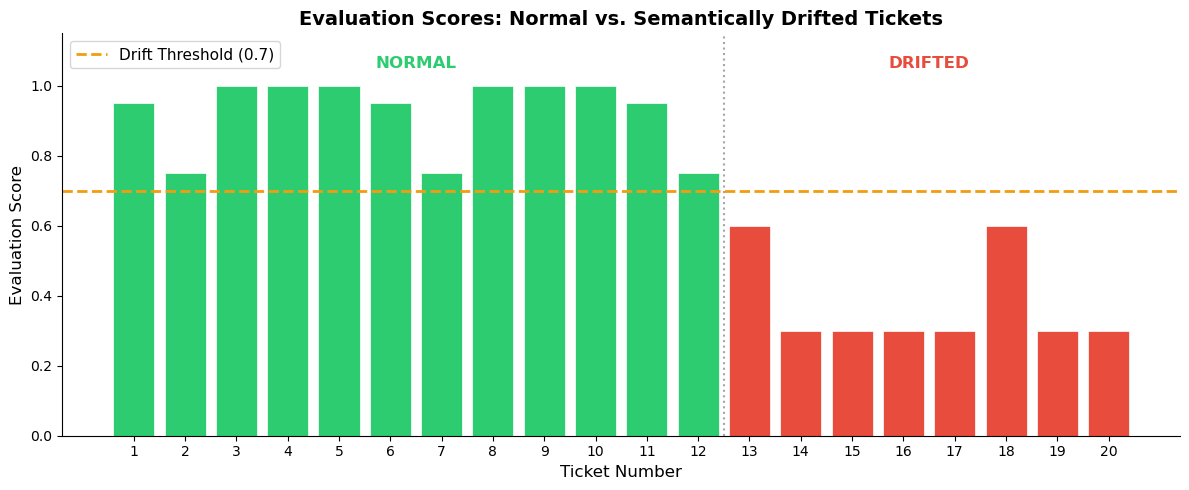

In [28]:
# ============================================================
# VISUALIZATIONS
# ============================================================

# --- Graph 1: Eval Score Per Ticket ---
fig, ax = plt.subplots(figsize=(12, 5))
scores = [t.eval_score for t in final_obs.traces]
colors = ['#2ecc71' if i < 12 else '#e74c3c' for i in range(len(scores))]
ax.bar(range(1, 21), scores, color=colors, edgecolor='white', linewidth=0.5)
ax.axhline(y=0.7, color='#f39c12', linestyle='--', linewidth=2, label='Drift Threshold (0.7)')
ax.axvline(x=12.5, color='gray', linestyle=':', linewidth=1.5, alpha=0.7)
ax.text(6.5, 1.05, 'NORMAL', ha='center', fontsize=12, fontweight='bold', color='#2ecc71')
ax.text(16.5, 1.05, 'DRIFTED', ha='center', fontsize=12, fontweight='bold', color='#e74c3c')
ax.set_xlabel('Ticket Number', fontsize=12)
ax.set_ylabel('Evaluation Score', fontsize=12)
ax.set_title('Evaluation Scores: Normal vs. Semantically Drifted Tickets', fontsize=14, fontweight='bold')
ax.set_ylim(0, 1.15)
ax.set_xticks(range(1, 21))
ax.legend(fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

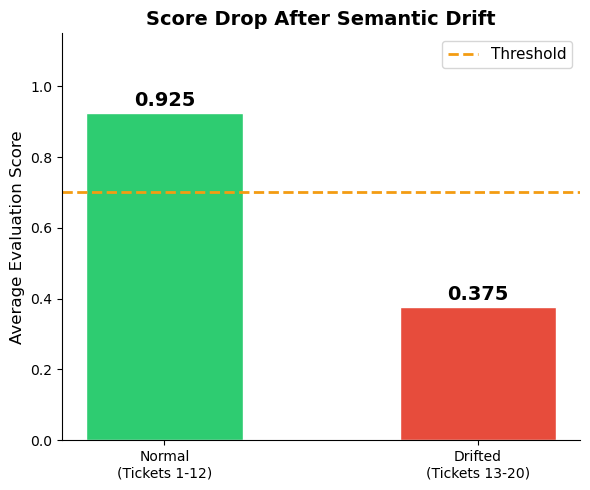

In [29]:
# --- Graph 2: Before vs After Drift ---
fig, ax = plt.subplots(figsize=(6, 5))
before_avg = sum(scores[:12]) / len(scores[:12])
after_avg = sum(scores[12:]) / len(scores[12:])
bars = ax.bar(['Normal\n(Tickets 1-12)', 'Drifted\n(Tickets 13-20)'],
              [before_avg, after_avg],
              color=['#2ecc71', '#e74c3c'], edgecolor='white', width=0.5)
ax.axhline(y=0.7, color='#f39c12', linestyle='--', linewidth=2, label='Threshold')
for bar, val in zip(bars, [before_avg, after_avg]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:.3f}', ha='center', fontsize=14, fontweight='bold')
ax.set_ylabel('Average Evaluation Score', fontsize=12)
ax.set_title('Score Drop After Semantic Drift', fontsize=14, fontweight='bold')
ax.set_ylim(0, 1.15)
ax.legend(fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

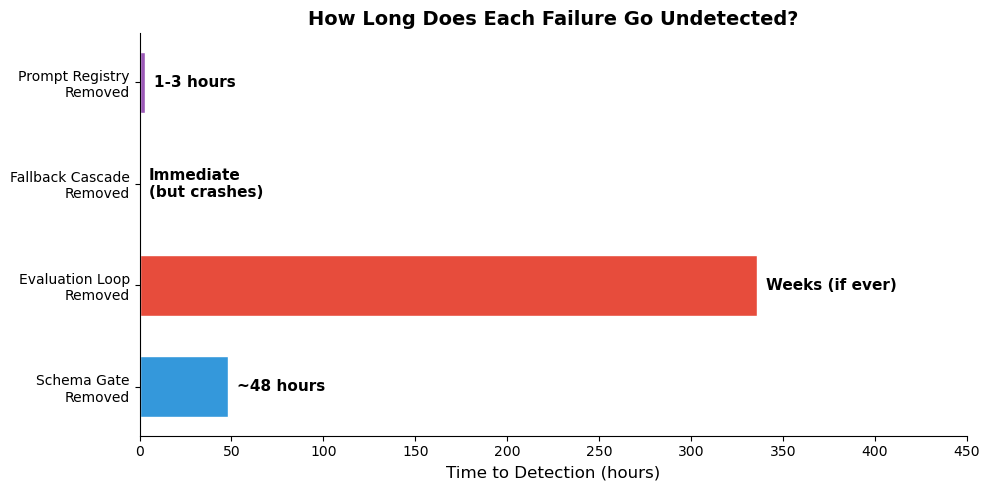

In [30]:
# --- Graph 3: Detection Time by Wall Removed ---
fig, ax = plt.subplots(figsize=(10, 5))
walls = ['Schema Gate\nRemoved', 'Evaluation Loop\nRemoved',
         'Fallback Cascade\nRemoved', 'Prompt Registry\nRemoved']
detection_hours = [48, 336, 0.01, 3]
colors_walls = ['#3498db', '#e74c3c', '#f39c12', '#9b59b6']
bars = ax.barh(walls, detection_hours, color=colors_walls, edgecolor='white', height=0.6)
labels = ['~48 hours', 'Weeks (if ever)', 'Immediate\n(but crashes)', '1-3 hours']
for bar, label in zip(bars, labels):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            label, va='center', fontsize=11, fontweight='bold')
ax.set_xlabel('Time to Detection (hours)', fontsize=12)
ax.set_title('How Long Does Each Failure Go Undetected?', fontsize=14, fontweight='bold')
ax.set_xlim(0, 450)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

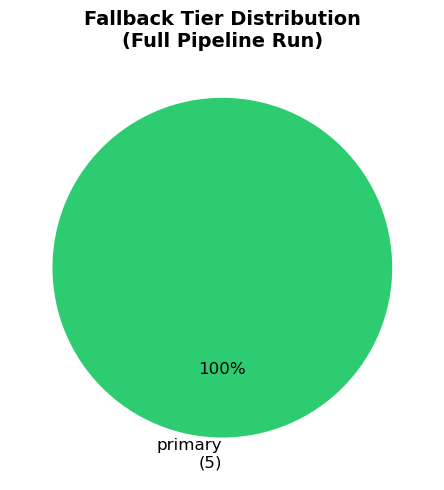

In [31]:
# --- Graph 4: Fallback Tier Distribution ---
fig, ax = plt.subplots(figsize=(7, 5))
tier_data = obs.summary()['tier_distribution']
tier_names = list(tier_data.keys())
tier_counts = list(tier_data.values())
tier_colors = {'primary': '#2ecc71', 'retry': '#3498db',
               'simpler_model': '#f39c12', 'cache': '#9b59b6', 'default': '#e74c3c'}
pie_colors = [tier_colors.get(t, '#95a5a6') for t in tier_names]
ax.pie(tier_counts, labels=[f"{n}\n({c})" for n, c in zip(tier_names, tier_counts)],
       colors=pie_colors, autopct='%1.0f%%', startangle=90,
       textprops={'fontsize': 12}, pctdistance=0.6)
ax.set_title('Fallback Tier Distribution\n(Full Pipeline Run)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

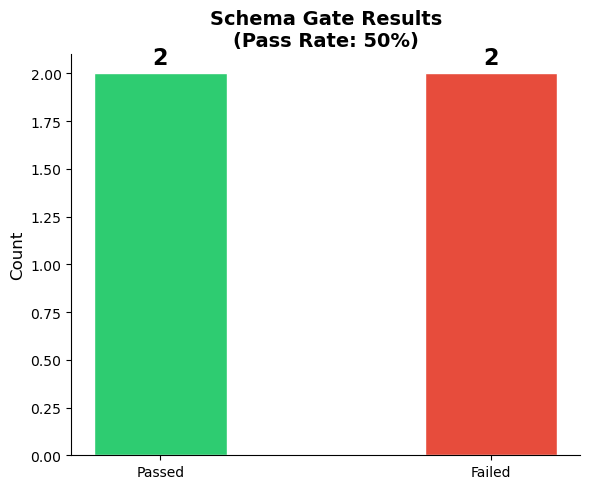

In [32]:
# --- Graph 5: Schema Gate Pass/Fail ---
fig, ax = plt.subplots(figsize=(6, 5))
gate_stats = gate.stats()
ax.bar(['Passed', 'Failed'],
       [gate_stats['passed'], gate_stats['failed']],
       color=['#2ecc71', '#e74c3c'], edgecolor='white', width=0.4)
for i, val in enumerate([gate_stats['passed'], gate_stats['failed']]):
    ax.text(i, val + 0.05, str(val), ha='center', fontsize=16, fontweight='bold')
ax.set_ylabel('Count', fontsize=12)
ax.set_title(f"Schema Gate Results\n(Pass Rate: {gate_stats['pass_rate']:.0%})",
             fontsize=14, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

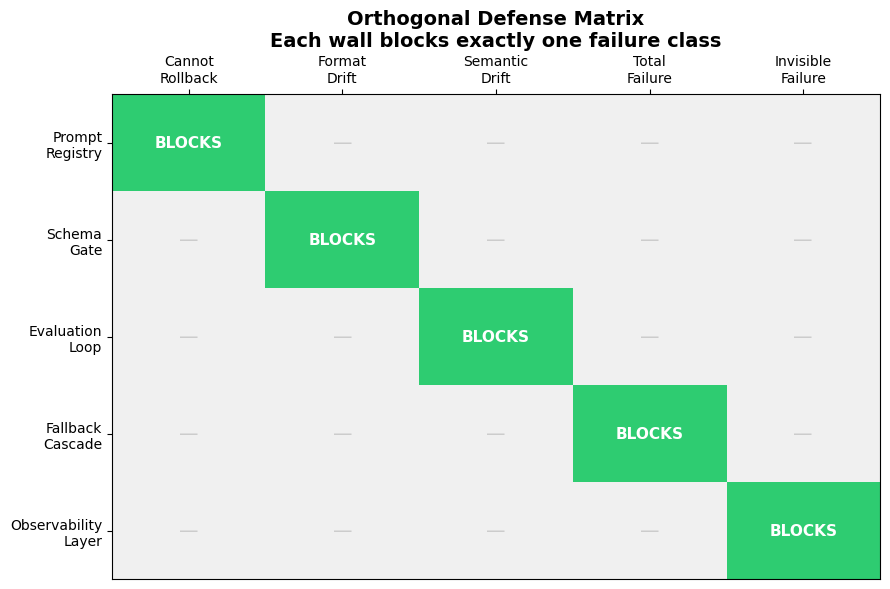

In [33]:
# --- Graph 6: Orthogonal Defense Matrix Heatmap ---
fig, ax = plt.subplots(figsize=(9, 6))
walls_list = ['Prompt\nRegistry', 'Schema\nGate', 'Evaluation\nLoop',
              'Fallback\nCascade', 'Observability\nLayer']
failures = ['Cannot\nRollback', 'Format\nDrift', 'Semantic\nDrift',
            'Total\nFailure', 'Invisible\nFailure']
matrix = np.eye(5)
cmap = plt.cm.colors.ListedColormap(['#f0f0f0', '#2ecc71'])
ax.imshow(matrix, cmap=cmap, aspect='auto')
for i in range(5):
    for j in range(5):
        if matrix[i][j] == 1:
            ax.text(j, i, 'BLOCKS', ha='center', va='center',
                    fontsize=11, fontweight='bold', color='white')
        else:
            ax.text(j, i, '—', ha='center', va='center',
                    fontsize=14, color='#cccccc')
ax.set_xticks(range(5))
ax.set_yticks(range(5))
ax.set_xticklabels(failures, fontsize=10)
ax.set_yticklabels(walls_list, fontsize=10)
ax.set_title('Orthogonal Defense Matrix\nEach wall blocks exactly one failure class',
             fontsize=14, fontweight='bold')
ax.tick_params(top=True, bottom=False, labeltop=True, labelbottom=False)
plt.tight_layout()
plt.show()

---
# CONCLUSION

1. The prototype-to-production gap is architectural, not about prompt quality.
2. Each wall blocks a distinct failure class no other wall can catch.
3. Semantic drift is the most dangerous production failure.
4. Graceful degradation is an architectural choice, not an afterthought.
5. If you cannot trigger the failure your architecture prevents,
   you do not understand your own system.

**Architecture is the leverage point. The model is just what executes
the architecture you designed.**

In [34]:
print("\n" + "=" * 60)
print("✅ NOTEBOOK COMPLETE")
print("=" * 60)
print("""
All five walls demonstrated. All four failure experiments triggered.
Human Decision Node documented. 6 visualizations generated.
Master argument: Architecture is the leverage point, not the model.
""")


✅ NOTEBOOK COMPLETE

All five walls demonstrated. All four failure experiments triggered.
Human Decision Node documented. 6 visualizations generated.
Master argument: Architecture is the leverage point, not the model.

